In [2]:
# Requires Noise2Void to be installed

from kymotools.detect import Detector
from kymotools.interactive import retain_tracks_by_id
from kymotools.kymo import PeakMeasures
from kymotools.msd import MSD
from n2v.models import N2V

import csv
import datetime
import kymotools.io as kio
import matplotlib.pyplot as plt
import numpy as np
import os


In [3]:
# Directory
path = "./examples/input/"
channel = 0

In [4]:
# Initialising Detector
detector = Detector(half_t_w=1, peak_det_thresh=1, n_max=6, a_lb = 0.5, c_lb=2, c_ub=12, c_def=6, max_dist=18, min_track_length = 9,
                    track_heritage_weight=100, starting_window=10)

In [5]:
def process(path, channel, detector, model):
    rootpath = os.path.dirname(path)+'/'
    rootname = os.path.basename(os.path.splitext(path)[0])

    # Getting image
    image = kio.read_image(path,channel,x_range=(1,None))
    (spatial_scale,spatial_units,time_scale,time_units) = kio.read_image_calibration(path)

    if model is not None:
        pred_image = model.predict(image, axes='YX', n_tiles=(2,1))
        image = pred_image - np.min(pred_image[:])
    
    # Detect peaks and track
    tracks = detector.detect(image)

    # Removing tracks
    kio.save_overlay(tracks,image,rootpath+rootname+'_C'+str(channel)+"_initial_overlay")
    display(kio.create_track_overlay(tracks,image))
    retain_tracks_by_id(tracks)
        
    # to_remove = []
    # for track in tracks.values():
    #     if os.path.isfile(rootpath+rootname+'_C'+str(channel)+"_InstantaneousMSD_zero_ID"+str(track.ID)+'.png'):
    #         print(str(track.ID)+" exists")
    #     else:
    #         to_remove.append(track.ID)
    #         print(str(track.ID)+" doesn't exist")
    # for id_to_remove in to_remove:
    #     tracks.pop(id_to_remove)

    display(kio.create_track_overlay(tracks,image))
    

    # Measure MSD
    for track in tracks.values():      
        # msd = MSD(track,spatial_scale=spatial_scale,spatial_units='um',time_scale=time_scale,time_units=time_units)
        # (D, intercept,perr) = msd.measure_diffusion_coefficient(max_dt=1,nonzero_intercept=False)
        # fig = msd.plot()
        # print('Zero intercept '+str(D))

        # (D, intercept,perr) = msd.measure_diffusion_coefficient(max_dt=1,nonzero_intercept=True)
        # fig = msd.plot()
        # print('Nonzero intercept '+str(D))
    
        # Calculating instantaneous MSD with zero intercept
        track.calculate_instantaneous_msd(half_w=15,spatial_scale=spatial_scale,spatial_units='um',time_scale=time_scale,time_units=time_units,calculate_D=True,max_dt=0.37, nonzero_intercept=False)
        x = list(track.peaks.keys())
        y = [peak.measures[PeakMeasures.INST_D_COEFF] for peak in track.peaks.values()]
        y = np.asarray([0 if v is None else v for v in y])

        # Saving instantaneous MSD
        fig = plt.figure()
        plt.plot(x,y,'black')
        plt.title('Track '+str(track.ID))
        plt.xlabel('Timepoint')
        plt.ylabel('Instantaneous diffusion coefficient')
        fig.savefig(rootpath+rootname+'_C'+str(channel)+"_InstantaneousMSD_zero_ID"+str(track.ID)+'.png')
        plt.show()
        kio.write_peak_data(track.peaks, rootpath+rootname+'_C'+str(channel)+"_InstantaneousMSD_zero_ID"+str(track.ID)+'.csv', extra_columns=[PeakMeasures.INST_D_COEFF])

    # Saving files
    kio.save_overlay(tracks,image,rootpath+rootname+'_C'+str(channel)+"_overlay")
    kio.write_track_data(tracks,rootpath+rootname+'_C'+str(channel)+"_traces")


Loading network weights from '2024-02-02_Cropped_Keras.h5'.
Processing:  20230613-163123 Kymograph 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


 50%|█████████████████████                     | 1/2 [00:00<00:00, 30174.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


100%|██████████████████████████████████████| 1269/1269 [00:02<00:00, 496.99it/s]


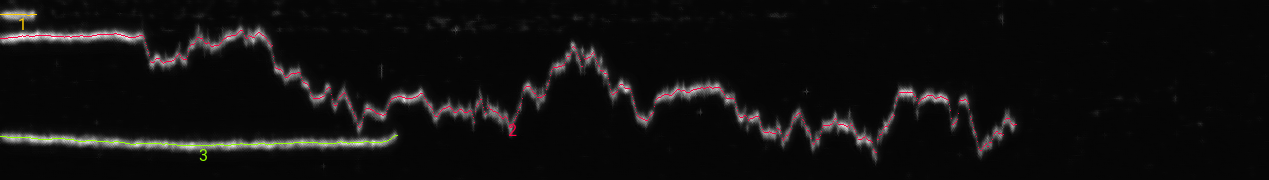

Enter track IDs to retain (comma-separated list):  2,3


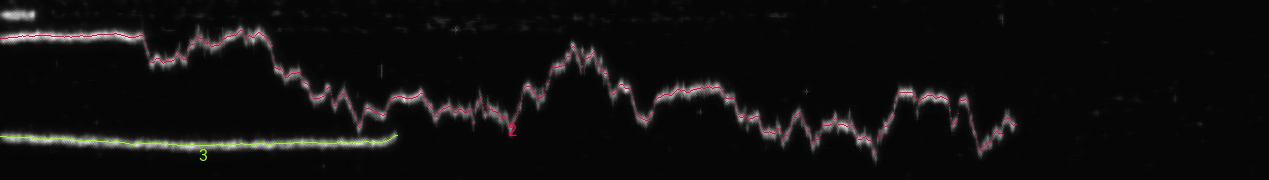

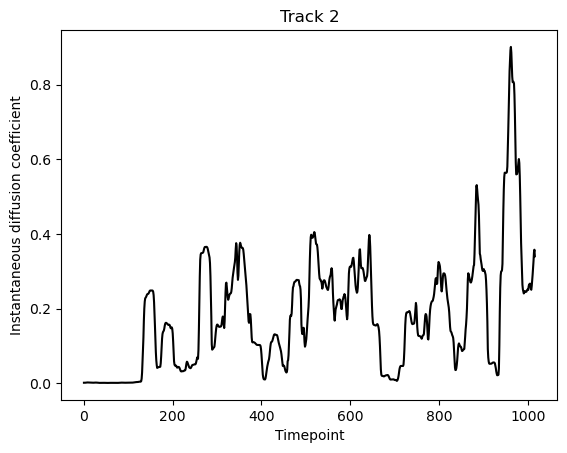

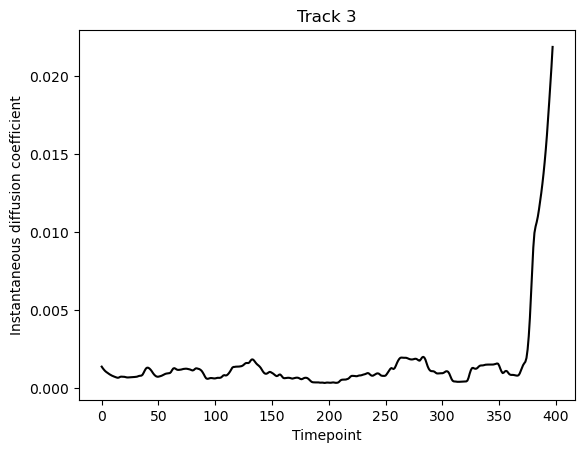

In [6]:
# Loading N2V model
model_name = '2024-02-02_Cropped_Keras'
model = N2V(config=None, name=model_name, basedir="./n2v-models/")
# model = None

# Calculating diffusion coefficients
for f in os.listdir(path):
    name = os.path.basename(os.path.splitext(f)[0])
    if os.path.splitext(f)[1] == ".tif":
        print("Processing: ",name)
        tracks = process(path+"/"+f, channel, detector, model)
            